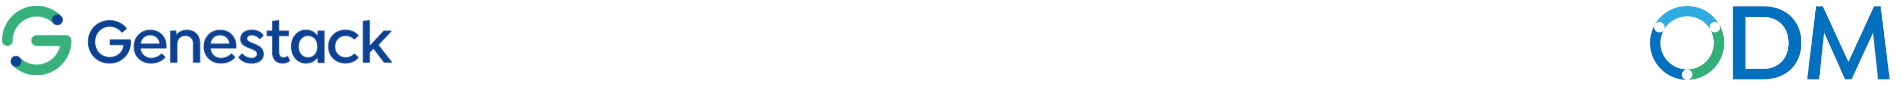

# Single-Cell RNA-Seq: Data Transformation and Upload to ODM

**This notebook demonstrates how to use the Genestack ODM API to ingest single-cell RNA-seq data.**

**With this notebook users will be able to:**
- easily import single-cell datasets into ODM
- seamlessly curate metadata on sample, library and cell levels to a single standard
- integrate single-cell studies from different sources in one place

## We hope this notebook gives you a hands-on sense of the convenience that the Single-Cell Module provides. 

**Contact:** support@genestack.com &nbsp;·&nbsp; © 2026 Genestack.

---

## Prerequisites
Run this section for the initialization and setup.

### Installation

From the unzipped demo folder (the directory that contains `setup.py` and `demo_utils/`), install the local helper package and dependencies into the active notebook kernel.

In [1]:
from pathlib import Path
from importlib.metadata import distribution

ROOT = Path.cwd() # or Path('/path/to/demo/folder')

try:
    distribution('demo_utils')
    print('demo_utils already installed')
except Exception:
    %pip install -e "{ROOT}"

demo_utils already installed


Alternatively, you can install the dependencies into the Python environment (must be the same as the notebook kernel) via the terminal command:
```bash
python -m pip install -e .
```

### Imports
This subsection imports needed modules and packages.

In [2]:
# standard library (come with Python)
import re
import subprocess
import warnings
import json

# third-party (need installation)
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Genestack ODM API (comes with odm-sdk)
import odm_api

# local helper functions
from demo_utils import (
    
    # connection / instrumentation
    set_api_configuration,
    odm_timer,
    display_odm_timing,

    # logs extraction
    display_log_records,
    extract_accessions_from_logs,

    # data handling
    flatten_value,
    clean_expression_metadata,
    create_full_matrix,
    display_collapsible_table,
)

# local settings
plt.style.use('default')
warnings.filterwarnings('ignore', category=FutureWarning)

### Authentication
Run this cell to set ODM API credentials. Either enter your ODM token manually in the interactive form, or store it in a `.env` file as `ODM_API_TOKEN=...`.

If Azure authentication is available for your account, instead set `use_azure_auth=True` in `set_api_configuration` and sign in through the **interactive browser-based Microsoft Azure authentication**.

In [3]:
server = 'https://single-cell-evaluation.dev.gs.team/' 

api_client = set_api_configuration(server, use_azure_auth=False)

config = api_client.configuration
if 'Access-token' in config.api_key:
    token_flag, token = '--access-token', config.api_key['Access-token']
else:
    token_flag, token = '--token', config.api_key['Genestack-API-Token']

'ODM_API_TOKEN' not found in environment or .env. Falling back to manual input.
Token authentication successful! Docs: https://single-cell-evaluation.dev.gs.team/user-docs/tools/odm-api/python/generated/


## What can be done with this Notebook

This notebook guides the process of uploading a single-cell study with the [Processors Controller APIs](https://single-cell-evaluation.dev.gs.team/swagger/?urls.primaryName=processorsController):

1. **Import a dataset into ODM with `odm-import-data` CLI tool**, attaching the single-cell file.
2. **Explore the available transformation images**, including their supported input/output formats and versioning.
3. **Retrieve available transformation configurations**, explore the structure of single-cell transformation configuration, and choose the needed configuration.
4. **Launch and monitor transformation jobs**, including a 'dry_run' validation mode, status checks and logs.
5. **Inspect the results of the transformation job.** Filter and export harmonized and indexed single-cell data.

Most steps call ODM API live. The blue **⏱ timers** show query running time.

## Step 1. Dataset import
**This section imports a publicly available scRNA-seq dataset into ODM as a starting point.**

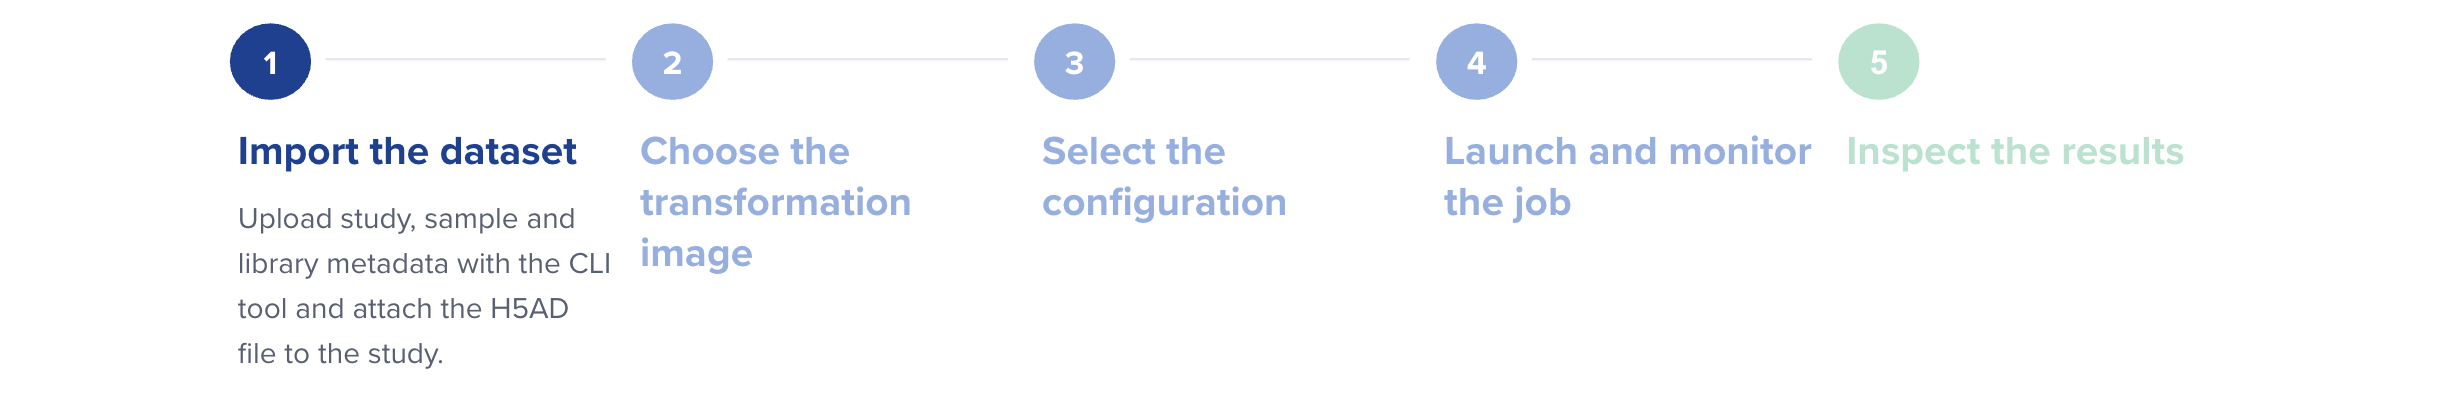

### 1.1 Import a study

This Notebook uses a fibrotic liver single-nucleus RNA-seq study as an example (Watson et al., 2023; GEO accession GSE210077). Any public dataset can be imported, as long as its data and metadata are staged in an S3 bucket in an appropriate format. More examples of curated public datasets can be found in [ODM documentation](https://single-cell-evaluation.dev.gs.team/user-docs/user-guide/doc-odm-user-guide/transformations/single-cell/curated-public-datasets/#configuration-index). 

<table>
  <thead>
    <tr>
      <th>Time for transformation</th>
      <th>Datasets</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>5 minutes or less</td>
      <td>FibroticLiverWatsonMERFISH · GSE165045 · GSE198623_pig</td>
    </tr>
    <tr>
      <td>10 minutes or less</td>
      <td>GSE198623_human · GSE292928</td>
    </tr>
    <tr>
      <td>Less than an hour</td>
      <td>HeartDiversityTucker10x · GSE192740_human</td>
    </tr>
    <tr>
      <td>Less than 2 hours</td>
      <td>GSE192740_mouse · SCP1303</td>
    </tr>
    <tr>
      <td>More than 2 hours</td>
      <td>GSE148434 · GSE156793 · GSE148073</td>
    </tr>
  </tbody>
</table>

The `odm-import-data` CLI tool uploads the following assets to ODM:
- **Study metadata** — the top-level study record.
- **Sample and library metadata** — biological and sequencing-level metadata for each specimen.
- **The H5AD file** — attached to the study as a non-indexed file that is going to be transformed. The accession returned for this attachment is required when submitting a transformation job.

In [4]:
with odm_timer("Importing single-cell dataset"):
    import_data = subprocess.run([
        "odm-import-data",
        "--server", server,
        token_flag, token,
        "--study", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/study.tsv",
        "--samples", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/samples.tsv",
        "--libraries", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/libraries.tsv",
        "-fl", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/GSE210077_adata_healthy_diseased_nucseq_sparse.h5ad",
        "-flm", "https://bio-test-data.s3.us-east-1.amazonaws.com/demo_materials/non_onco/single_cell/inflammatory_diseases/FibroticLiverWatsonMERFISH/data.tsv",
        "-dc", "Single-cell transcriptomics",
        "--template", "GSF000057",
        "--allow-duplicates"
    ], capture_output=True, text=True)

### 1.2 Check an attachment accession
Retrieve attachment accession from import logs.

In [5]:
# retrieve file accession from import logs
try:
    match = re.search(r"file (\w+) was attached successfully", import_data.stdout)
    attachment_accession = match.group(1)
    print(f'Data imported successfully. Attachment accession: {attachment_accession}')
except:
    match = re.search(r"Error message from server:\n(.*)", import_data.stderr)
    server_error = match.group(1).strip() if match else None
    print(f'Error: {server_error}')

Data imported successfully. Attachment accession: GSF112461


## Step 2. Transformation Image

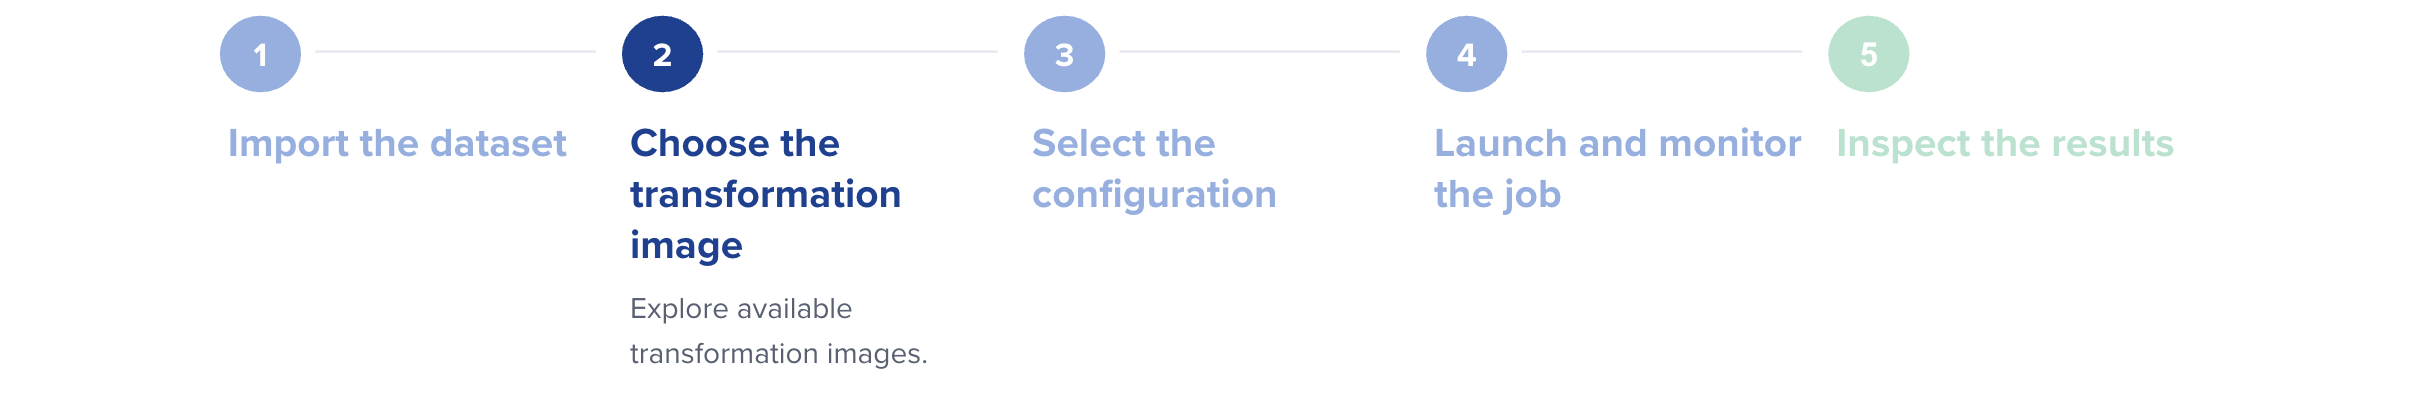

**A transformation image is a versioned container that executes the processing logic for a given file type.**

Transformation images are released by Genestack team. Each image declares the input formats it accepts and the output entity types it can produce. When submitting a job, an image should be selected by name and version.

- **Name:** For single-cell HDF5 files, the relevant image name is **`hdf5-cells`**. It accepts `h5ad` and `h5` inputs, produces Cell Group and Expression Group outputs, and can also create or update Samples, Libraries, and Preparations.

- **Version**: You can use `"latest"` to always run with the most recent released image or specify a version tag for reproducibility.

### 2.1 Retrieve available Transformation Images
`get_api_v1_transformations_images()` returns all transformation images available on the ODM instance. 

The cell below filters for `version == "latest"` entries and prints the name, description, accepted input formats, and producible output types for each image. Use this to confirm that the `hdf5-cells` image is available and to identify its supported input/output formats before submitting a job.

In [6]:
# initialize API class
images_api = odm_api.TransformationImagesApi(api_client)

# call the API method to get the list of transformation images
with odm_timer("Retrieving transformation images list"):
    response = images_api.get_api_v1_transformations_images()

# extract and print relevant information for each image
for image in response.items:
    if getattr(image, 'version', '') == 'latest':
        print(f"Name: {getattr(image, 'name', '')}")
        print(f"Description: {getattr(image, 'description', '')}")
        print(f"Input formats: {getattr(image, 'input_formats', [])}")
        print(f"Output formats: {getattr(image, 'output_formats', [])}")
        print('-' * 40)

Name: hdf5-cells
Description: Import single-cell data and metadata from HDF5 format to ODM
Input formats: ['h5ad', 'h5']
Output formats: [<TransformationOutputFormat.SAMPLES: 'samples'>, <TransformationOutputFormat.LIBRARIES: 'libraries'>, <TransformationOutputFormat.PREPARATIONS: 'preparations'>, <TransformationOutputFormat.CELLS: 'cells'>, <TransformationOutputFormat.EXPRESSIONS: 'expressions'>]
----------------------------------------
Name: metadata-basic
Description: Basic converter from attachment to metadata
Input formats: ['csv']
Output formats: [<TransformationOutputFormat.SAMPLES: 'samples'>]
----------------------------------------


## Step 3. Transformation Configuration

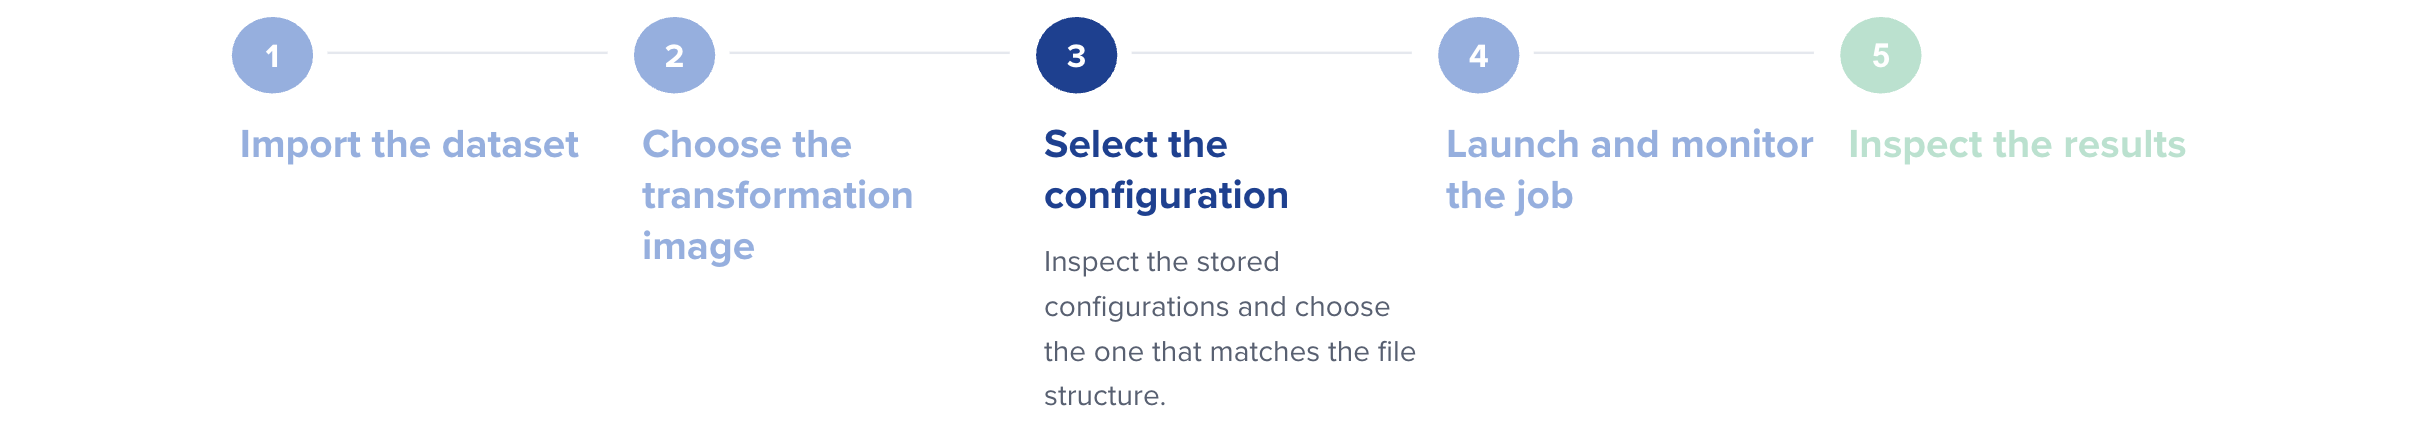

**A transformation configuration is a JSON document stored in ODM that sets the detailed parameters for the transformation process defined by the image.**

Unlike transformation images, which ship with Genestack releases, configurations can be created and edited by users independently, so the transformation can be fine-tuned to your needs. A configuration may contain rules for:

- specifying the parts of the file to extract
- harmonizing cell attributes names and values across datasets, e.g. cell types
- extracting cell attributes to higher levels (sample, library or preparation) to avoid duplication


Together, these let you customize the transformation end to end: curating studies as you import them and harmonising datasets from different sources in a single step.

Configurations are stored independently of any particular job, so the same configuration can be reused for all files with the same structure in an established ingestion pipeline. This section shows how to list the available configurations and inspect them.

### 3.1 Retrieve available transformation configurations
`get_api_v1_transformations_configurations()` returns all configurations stored in your ODM instance. Each entry includes an `id`, `name`, `description` and the actual `data`. The `id` is the key identifier used in all subsequent API calls to reference, update, or run a job against a specific configuration.

#### Mapping table (Which config to use)

The table below maps the default configurations on the instance to the public datasets they apply to.
<table>
  <thead>
    <tr>
      <th>Configuration</th>
      <th>Datasets</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>aggregated_config_1</td>
      <td>HeartDiversityTucker10x · SCP1303 · GSE192740_human · GSE192740_mouse · GSE292928 · GSE148434</td>
    </tr>
    <tr>
      <td>aggregated_config_2</td>
      <td>GSE198623_human · GSE198623_pig</td>
    </tr>
    <tr>
      <td>aggregated_config_3</td>
      <td>GSE148073 · FibroticLiverWatsonMERFISH</td>
    </tr>
    <tr>
      <td>GSE156793</td>
      <td>GSE156793</td>
    </tr>
    <tr>
      <td>GSE165045</td>
      <td>GSE165045</td>
    </tr>
  </tbody>
</table>

In [7]:
# initialize API class
configurations_api = odm_api.TransformationConfigurationsApi(api_client)

# retrieve and display the available transformation configurations
with odm_timer("Retrieving transformation configurations list"):
    configs = configurations_api.get_api_v1_transformations_configurations()
if configs.total > 0:
    df = pd.DataFrame([{
        'id': getattr(cfg, 'id', ''),
        'name': getattr(cfg, 'name', ''),
        'description': getattr(cfg, 'description', '')
    } for cfg in configs.items])
    display(HTML(df.to_html(index=False)))
else:
    display(HTML("<div style='color: red;'>No transformation configurations available.</div>"))

id,name,description
1,GTEx_config.json,Configuration to transform GTEx atlases
2,GSE328048.json,"Config for GSE328048. Raw counts are stored in X. Library linking uses sample_label values such as 5917-AB-2, matching ODM Library ID values. QC metadata columns are preserved for cohort filtering."
3,sc_cell_harmonisation.json,Configuration to transform single-cell data harmonising cell type labels
4,cellxgene_config.json,Configuration to transform cellxgene data
5,aggregated_config_1.json,Aggregated config 1 to transform several public datasets
6,aggregated_config_2.json,Aggregated config 2 to transform several public datasets
7,aggregated_config_3.json,Aggregated config 3 to transform several public datasets
8,GSE156793.json,Config to transform GSE156793 dataset
9,GSE165045.json,Config to transform GSE165045 dataset


### 3.2 Select transformation configuration
Retrieve the details of the configuration to make an informed decision.

A detailed guidance on how to apply curation operations is available in the ODM [User Guide](https://single-cell-evaluation.dev.gs.team/user-docs/user-guide/doc-odm-user-guide/transformations/single-cell/configure-metadata-curation/).

In [8]:
with odm_timer("Retrieving transformation configuration details"):
    config_id = 7
    config = configurations_api.get_api_v1_transformations_configurations_by_id(config_id)
print(json.dumps(json.loads(config.to_json()), indent=2))

{
  "create_time": "2026-08-10T17:19:37Z",
  "data": {
    "biosample_metadata": {
      "biosample_column_name": "sample_id",
      "library": {
        "columns_to_curate_values": null,
        "columns_to_export": null,
        "columns_to_fill_missing_values": null,
        "create_new_group": null,
        "linking_group": null,
        "template_id": null
      },
      "metadata_keys": {
        "obs": "metadata"
      },
      "sample": {
        "columns_renaming_map": {
          "Condition": "Condition Group",
          "self_reported_ethnicity_ontology_term_id": "Donor Ethnicity Term ID",
          "tissue_type": "Cell Source"
        },
        "columns_to_curate_values": {
          "Sample Source ID": {
            "AM031": "Liver-32",
            "AM042": "Liver-13",
            "AM048": "Liver-14",
            "AM061": "Liver-18",
            "AM062": "Liver-33",
            "AM072": "Liver-34"
          }
        },
        "columns_to_export": [
          "Condition"

## Step 4. Transformation Job

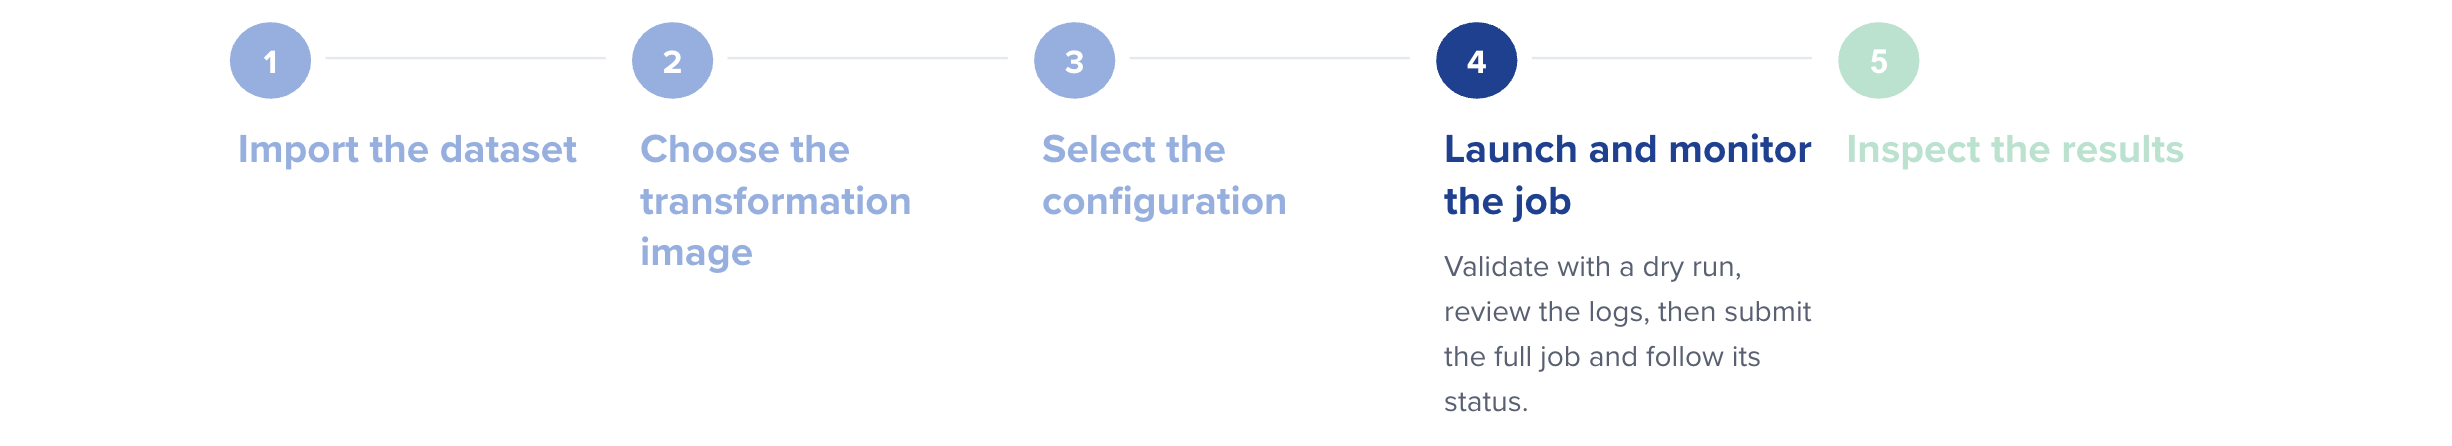

**A transformation job is a single run of the transformation image for the provided source file using the specified configuration.**

The API responds immediately with a `job_id`, which is then used to check the status and retrieve logs once the run is complete.

The recommended workflow is:

1. **Submit a `dry_run` job** to validate the configuration without uploading any data to ODM. The pipeline runs all metadata extraction and curation steps and reports the file structure, any column mapping issues, and linking validation results.
2. **Review the logs** and update the configuration if needed. Repeat until the dry run completes with status `DONE` and no undesired warnings.
3. **Submit the full job** (`dry_run=False`) to ingest the data. The pipeline compresses the expression matrix, imports all objects to ODM (Cell Group, Expression Group, and any Samples, Libraries, or Preparations updates), and links them to the appropriate entity.

This approach helps you catch issues early, saving time and preventing unwanted changes to your data. Once the dry run completes successfully, you can confidently proceed to run the actual transformation job. More details can be found in the corresponding section in the [User Guide](https://single-cell-evaluation.dev.gs.team/user-docs/user-guide/doc-odm-user-guide/transformations/single-cell/iterate-with-dry-runs/#the-iteration-cycle).

Dry run iteration cycle:
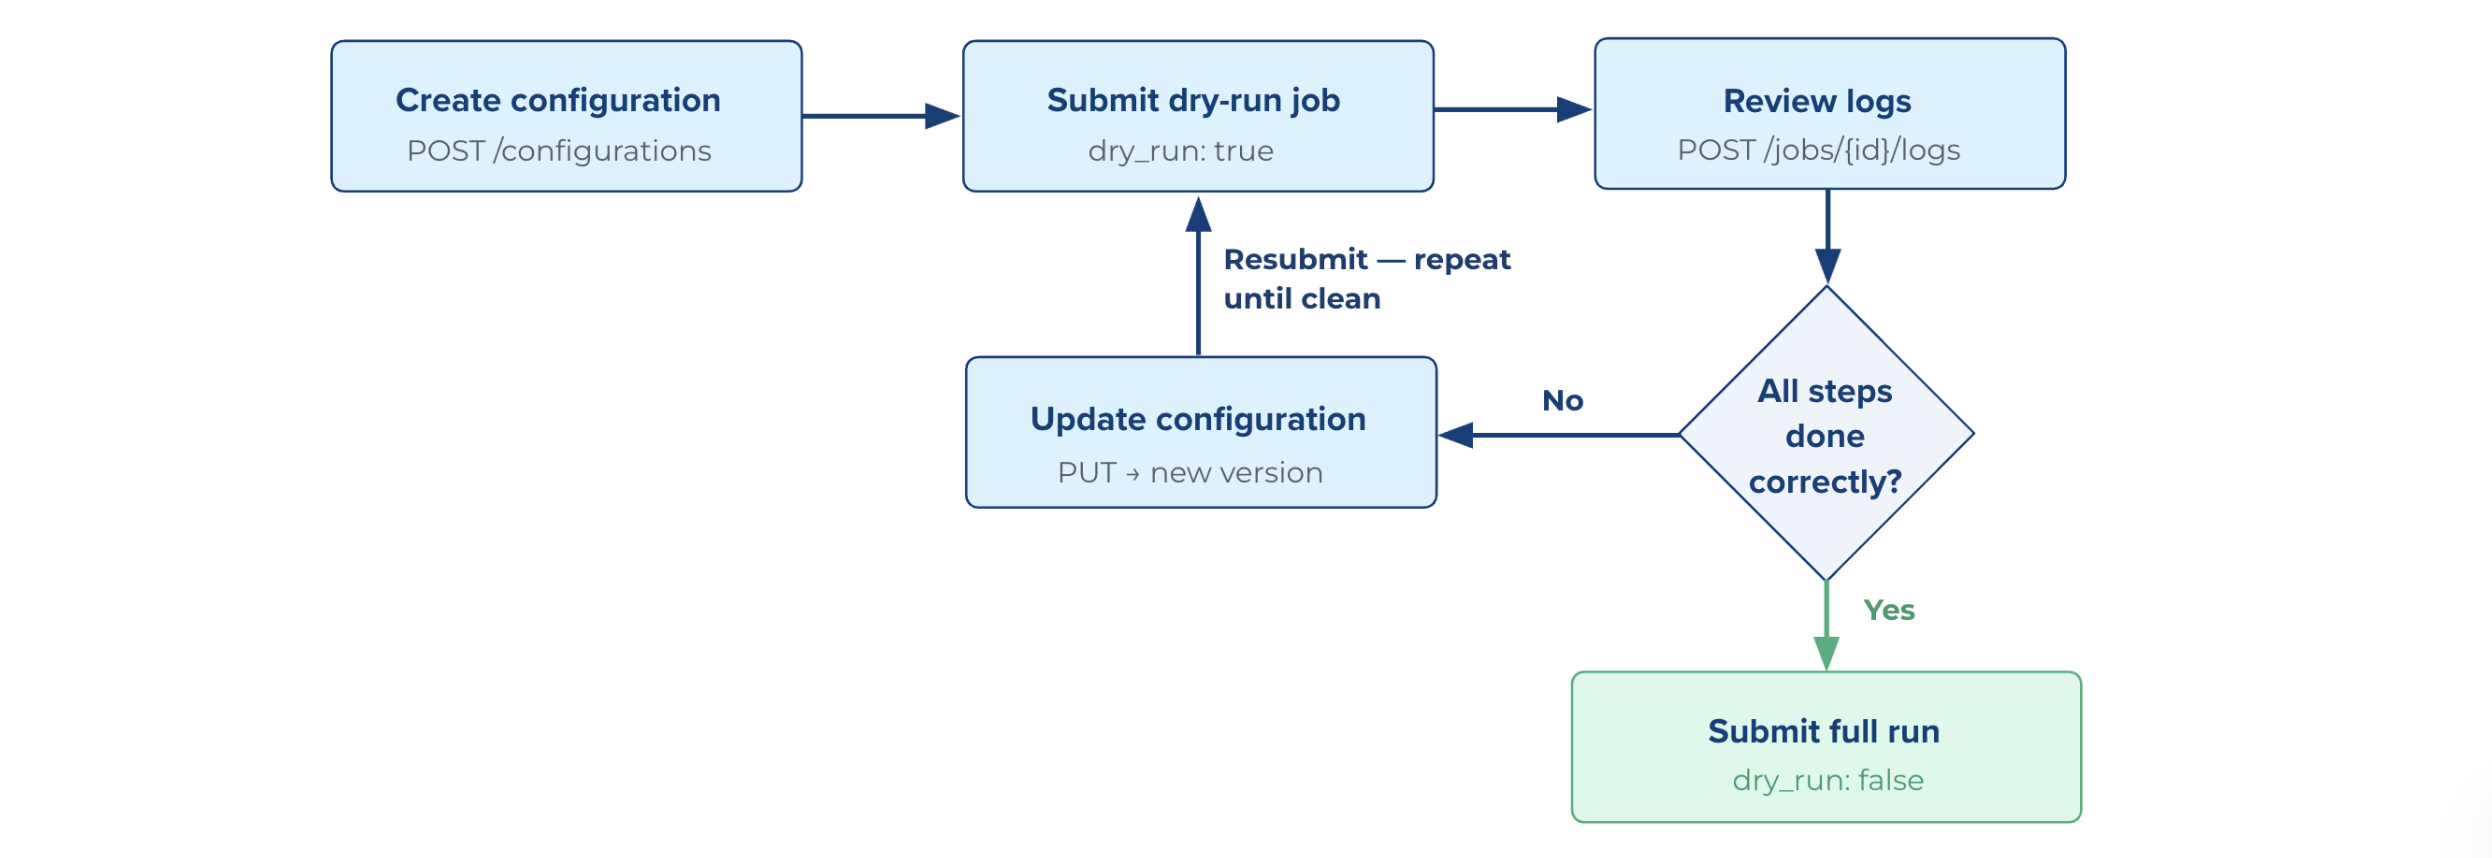

### 4.1 Set job parameters
Choose an ID and a version for the Image and the Configuration used for the transformation. `input_accessions` uses an accession of the H5AD attachment that was imported in the Step 1. 

`volume_size` and `memory_size` can also be set:

- `volume_size` sets the disk space allocated for processing. For H5AD input files, allocate at least 1.4× the original file size; for 10x H5 input files, at least 4×.
- `memory_size` sets the RAM allocated for processing. Increase it if a job ends as FAILED with status.reason: `OOMKilled` (out-of-memory termination).

In [9]:
# initialize API class
jobs_api = odm_api.TransformationJobsApi(api_client)

transformation_job_create_fields = odm_api.TransformationJobCreateFields(
    configuration_reference=odm_api.TransformationConfigurationReference(
        id=int(config_id),
    ),
    configuration_version=1,
    dry_run=False,
    image_reference=odm_api.TransformationImageReference(
        name="hdf5-cells",
        version="0.1.2"
    ),
    input_accessions=[attachment_accession],
    volume_size="30Gi",
    memory_size="20Gi"
)

### 4.2 Retrieve job ID
The retrieved job ID is used to check the job status and retrieve the logs.

In [10]:
# call the transformation job
with odm_timer("Submitting transformation job"):
    response = jobs_api.post_api_v1_transformations_jobs(transformation_job_create_fields)

# retrieve job ID from response
job_id = response.id
print(f"Job ID: {job_id}")

Job ID: 83


### 4.3 Check status
Possible statuses:

- `PENDING`: accepted and queued, not yet scheduled
- `WAITING`: scheduled and waiting for compute resources
- `RUNNING`: actively executing
- `DONE`: completed successfully (terminal status)
- `FAILED`: stopped because of an error (terminal status)
- `CANCELLED`: cancelled before completion (terminal status)
- `UNKNOWN`: state could not be determined

In [14]:
# check job status 
with odm_timer("Checking job status"):
    job_status = jobs_api.get_api_v1_transformations_jobs_by_id(job_id)
    print(f"Job status: {job_status.status.state.value}")

# display job duration upon completion
if job_status.end_time:
    dt = job_status.end_time - job_status.create_time
    display_odm_timing("Transformation job duration", dt.total_seconds())

Job status: DONE


### 4.4 Explore logs
Retrieve and display logs from job ID.

In [15]:
if job_status.status.state.value not in ['PENDING', 'UNKNOWN', 'WAITING']:
    logs_payload = odm_api.LogsPayload()
    with odm_timer("Retrieving job logs"):
        logs = jobs_api.post_api_v1_transformations_jobs_by_id_logs(job_id, logs_payload)
    display_log_records(logs)
else:
    print("Transformation job has not started yet. Please rerun this cell once "
          "the job is in progress or completed.")

Time,Level,Message
2026-09-01 15:34:07.362418+00:00,INFO,Container memory size (cgroup v2): 20.00 GB.
2026-09-01 15:34:07.362696+00:00,INFO,Transformation job ID: 83.
2026-09-01 15:34:07.362914+00:00,INFO,Transformation image name: hdf5-cells.
2026-09-01 15:34:07.363106+00:00,INFO,Transformation image version: 0.1.2.
2026-09-01 15:34:07.363311+00:00,INFO,Transformation configuration ID: 7.
2026-09-01 15:34:07.363503+00:00,INFO,Transformation configuration version: 1.
2026-09-01 15:34:07.363775+00:00,INFO,Starting configuration validation...
2026-09-01 15:34:07.363950+00:00,INFO,Validating top-level configuration keys...
2026-09-01 15:34:07.364134+00:00,INFO,Validating biosample_metadata configuration...
2026-09-01 15:34:07.364316+00:00,INFO,Validating cell_metadata configuration...


## Step 5. Results of the Transformation Job

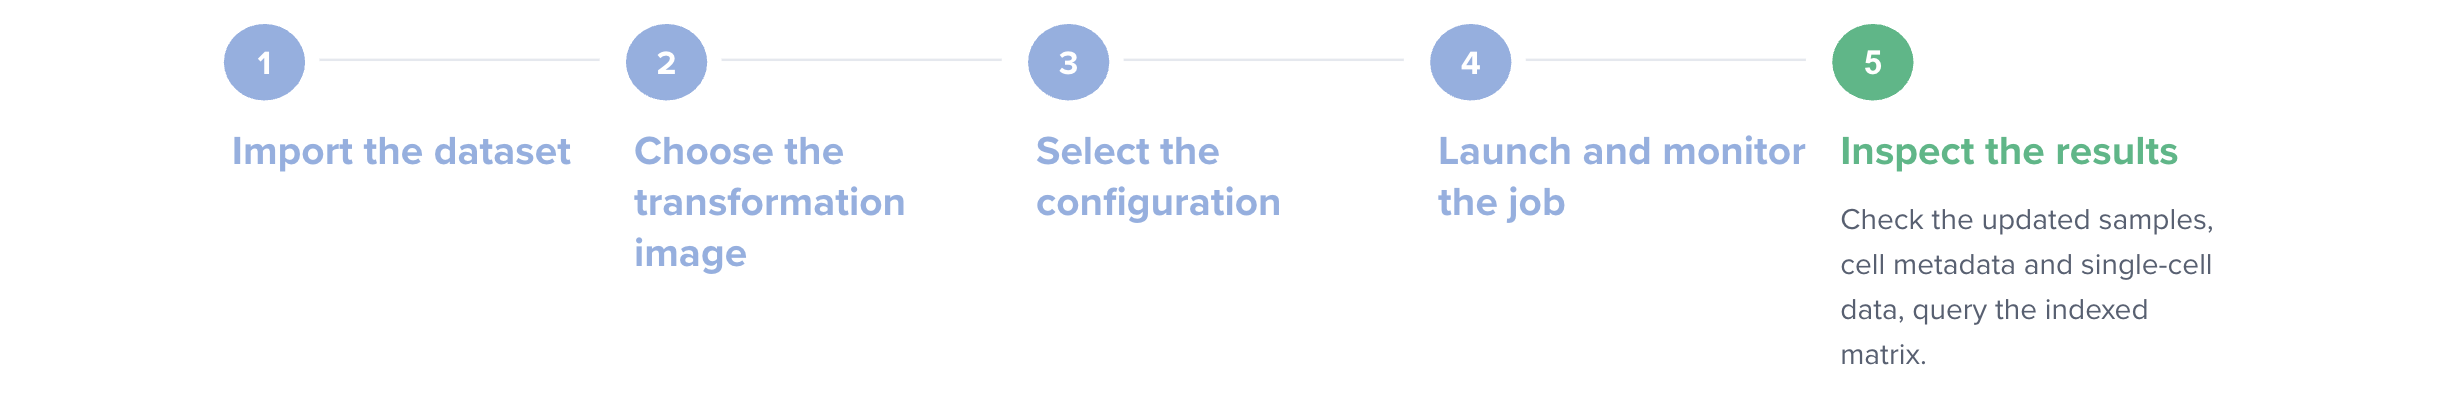

**After the transformation completes, the job logs contain the accessions of all objects created or updated.**

This section uses those accessions to verify the results via the relevant ODM API endpoints:

- **Updated biosample attributes** — confirm that Sample, Library, or Preparation Groups were correctly updated and exported.
- **Cell metadata** — inspect the per-cell annotations uploaded as a Cell Group.
- **Expression metadata** — review the summary statistics (cell count, feature count, sparsity, etc.) stored with the Expression Group.
- **Indexed expression data** — query the expression matrix with cell-level filters using the ODM Omics API.

In [16]:
# extract group accessions from transformation job logs
job_status = jobs_api.get_api_v1_transformations_jobs_by_id(job_id)
if job_status.status.state.value == 'DONE':
    accessions = extract_accessions_from_logs(logs)
    cell_group_accession = accessions['cell_group_accession']
    sample_group_accession = accessions['sample_group_accession']
    library_group_accession = accessions['library_group_accession']
    expression_group_accession = accessions['expression_group_accession']
    study_group_accession = accessions['study_group_accession']
else:
    print("Transformation job not completed. "
          "Please rerun this cell once the job has finished.")

### 5.1 Inspect updated biosample attributes
Because `biosample_metadata` was configured with `columns_to_export` for the `sample` entity, the transformation exported biosample-level attributes (e.g. `Condition Group`, `Donor Ethnicity Term ID`, `Cell Source`) from the cell metadata and merged them into the existing Sample Group in ODM. Those attributes were also removed from the cell metadata to avoid duplication.

The cell below retrieves the updated Sample Group metadata using `SampleSPoTAsUserApi.search_samples_as_user()` and the `sample_group_accession` extracted from the transformation logs, and displays the first few rows to verify that the exported and renamed attributes are present.

In [17]:
# initialize API client
sample_api = odm_api.SampleSPoTAsUserApi(api_client)

if job_status.status.state.value == 'DONE':
    # retrieve data by group accession
    with odm_timer("Retrieving sample group metadata"):
        sample_data = sample_api.search_samples_as_user(
            query=sample_group_accession,
            returned_metadata_fields="original_data_included"
        )
    data = sample_data.data
    samples_df = pd.DataFrame(data)
    display_collapsible_table("Sample group metadata", samples_df.head().to_html(index=False))

else:
    print("Transformation job not completed. "
          "Please rerun this cell once the job has finished.")


genestack:accession,GEO Sample ID,SRA ID,BioSample ID,Sample Name,Sample Source,Sample Source ID,Paired Sample,Disease,Disease Subtype,Disease Duration,Disease Duration Unit,Condition Group,Tissue,Tissue General,Tissue Type,Cell Source,Cell Type,Species,Donor ID,Donor Sex,Donor Ethnicity,Developmental Stage,Donor Age,Donor Age Range,Donor Age Unit,Body Mass Index (BMI) Value,Body Mass Index (BMI) Range,Body Mass Index (BMI) Unit,Tobacco Smoking History,Genotype,Sample Timepoint,Treatment / Pharmaceutical Therapy Compound,Clinical Response,Donor Remission Status,Inflammation Status,Inflammation Score,Donor Hardy Score,Comment,Date of Sampling,Donor Ethnicity Term ID,Sample Anatomical Site of Origin,groupId,Donor Fibrosis Stage
GSF112445,GSM6416567,None,None,AM042,Human Cell Atlas,Liver-13,None,Healthy,None,None,None,None,liver,None,None,None,None,Homo sapiens,None,female,None,human adult stage,51,51-60,year,None,None,None,None,None,None,None,None,None,None,None,None,healthy donor with absence of clear signs of acute or chronic injury,2024-10-31,unknown,liver,GSF112444,NaN
GSF112446,GSM6416569,None,None,AM048,Human Cell Atlas,Liver-14,None,Healthy,None,None,None,None,liver,None,None,None,None,Homo sapiens,None,male,None,human adult stage,61,61-70,year,None,None,None,None,None,None,None,None,None,None,None,None,healthy donor with absence of clear signs of acute or chronic injury,2024-10-31,unknown,liver,GSF112444,NaN
GSF112447,GSM6416578,None,None,AM061,Human Cell Atlas,Liver-18,None,Healthy,None,None,None,None,liver,None,None,None,None,Homo sapiens,None,female,None,human adult stage,81,81-90,year,None,None,None,None,None,None,None,None,None,None,None,None,healthy donor with absence of clear signs of acute or chronic injury,2024-10-31,unknown,liver,GSF112444,NaN
GSF112448,GSM8493744,None,None,AM031,Human Cell Atlas,Liver-32,None,liver cirrhosis,None,None,None,None,liver,None,None,None,None,Homo sapiens,None,male,None,human adult stage,51,51-60,year,None,None,None,None,None,None,None,None,None,None,None,None,fibrotic donor,2025-02-05,unknown,liver,GSF112444,F4
GSF112449,GSM8493745,None,None,AM062,Human Cell Atlas,Liver-33,None,liver fibroma,None,None,None,None,liver,None,None,None,None,Homo sapiens,None,female,None,human adult stage,41,41-50,year,None,None,None,None,None,None,None,None,None,None,None,None,fibrotic donor,2025-02-05,unknown,liver,GSF112444,F2


### 5.2 Inspect cell metadata
The Cell Group contains the per-cell annotations extracted from the H5AD file, curated according to the configuration.

The cell below retrieves the first rows of the Cell Group using `CellsAsUserApi.get_cells_by_group_as_user()`, identified by the `cell_group_accession` extracted from the transformation logs.

In [18]:
# initialize API client
cell_api = odm_api.CellsAsUserApi(api_client)

if job_status.status.state.value == 'DONE':
    # retrieve data by group accession
    with odm_timer("Retrieving cell group metadata"):
        cell_data = cell_api.get_cells_by_group_as_user(cell_group_accession)
    data = cell_data.data
    cells_df = pd.DataFrame(data)

    # set barcode as index
    cells_df = cells_df.set_index("barcode")
    display_collapsible_table("Cell group metadata", cells_df.head().to_html())
else:
    print("Transformation job not completed. "
          "Please rerun this cell once the job has finished.")

,cellId,batch,cellType,nCounts,percentMito,umap,pca,log10GenesPerUmiInjured,seuratClustersInjured,cellTypeInjured,cellTypeFinalInjured,log10GenesPerUmiHealthy,seuratClustersHealthy,cellTypeHealthy,cellTypeFinalHealthy,logCounts,nGenes,assayOntologyTermId,suspensionType,pcaHarmony,meanConnectivities,meanDistances,mitoCounts,riboCounts,percentRibo
barcode,,,,,,,,,,,,,,,,,,,,,,,,,
Liver.13_AAACCCAAGTTAGTAG.1-1,GSF112468-Liver.13_AAACCCAAGTTAGTAG.1-1,Liver-13,,10051,0.00000,"[-0.46331504, -4.2235503]","[12.137529, 10.891174, 0.12435753, -0.04747507, 0.69676274, -1.4906868, 0.08580877, 0.20459746, -0.20275217, -4.697879, -0.7076968, -3.4512851, 1.1164323, 0.76157415, 1.067887, -0.97995776, 2.3865936, -0.038163453, -0.4267018, 0.2038568, -0.28443533, -1.2139461, -0.8176204, -0.3590163, -0.20638464]",,,,,0.866669959359415,10,Hepatic_stellate_cells,HSC_1,9.215427,2928,,na,"10.553474,9.898809,-0.040885687,-0.24276683,0.62996423,-1.1808891,0.25137967,0.1368121,0.3095448,-2.5801508,-0.25513768,-3.1873329,0.66923505,0.67019945,0.7666667,-0.6618811,1.3341376,-0.109150626,0.02376286,0.23336272,0.18955815,-0.82932395,-0.5879295,0.13551255,-0.21027641",0.00048978464,0.0009054886964158516,0,15,0.14923888170331312
Liver.13_AAACCCACAATGTGGG.1-1,GSF112468-Liver.13_AAACCCACAATGTGGG.1-1,Liver-13,,5329,0.00000,"[10.219194, 4.1265607]","[-3.386281, -0.09895378, -0.04621607, -0.29931396, 0.5865491, -0.071433425, -0.71152914, 0.82993305, -2.580983, -0.53464556, -1.5554526, -0.4212112, 0.40156704, -1.4147602, -0.6464496, -1.3782663, -0.20468915, 0.75898725, -0.33518443, -0.036190875, 0.43066734, 0.43392974, 0.5888648, -0.20781413, -0.5582827]",,,,,0.898247925746093,0,Hepatocytes,Hep_1,8.580919,2221,,na,"-2.9538522,-0.21806423,-0.23180369,-0.4187424,-0.23022524,-0.44066992,0.22957425,0.3114095,-1.3132601,-0.5378268,-0.8687273,-0.34057027,-0.41601557,-0.85106146,-0.050436877,-0.7458186,-0.1769908,0.3803419,-0.48090598,0.13082139,0.2703654,0.34653482,0.52414215,-0.085541815,-0.18692447",0.00035890169,0.0007847628849323784,0,13,0.24394820791893415
Liver.13_AAACCCACACCTCGTT.1-1,GSF112468-Liver.13_AAACCCACACCTCGTT.1-1,Liver-13,,8119,0.03695,"[10.698837, 10.0404415]","[-3.237879, -0.2842459, 0.040820267, 0.41713125, 2.527977, 0.4704482, -0.6760496, 0.3635924, -1.2898221, -0.62887806, 0.00015130639, -0.12488869, 0.5154322, -1.6777186, -0.57207483, -0.7306467, -0.18149775, 0.5146872, 0.25703782, -0.3460521, -0.98864716, 0.3733704, 0.49249998, -0.27478778, -0.26778132]",,,,,0.890666783522695,12,Hepatocytes,Hep_1,9.001963,3027,,na,"-3.1251893,-0.28575116,0.45323956,0.7210219,1.4092761,0.48360983,1.7175963,-0.36678275,-0.4893254,-0.5937992,-0.11507254,-0.029103996,-0.31389016,-1.1276149,-0.13470866,-0.33079502,0.1342674,0.2205748,0.02598448,-0.0096917385,-0.84620255,0.25201228,0.46555117,0.0575808,-0.062030327",0.00021373578,0.0011001621671241609,3,26,0.3202364823254095
Liver.13_AAACCCACATGACAAA.1-1,GSF112468-Liver.13_AAACCCACATGACAAA.1-1,Liver-13,,1930,0.00000,"[-0.44443342, 1.6000901]","[3.0589175, 0.49618077, -3.0585284, -1.1382377, -4.4574466, 8.165003, -1.5523858, -2.9164038, 0.8543454, -0.6008927, -0.5070977, -0.8298889, 1.4379351, -0.66211635, -0.64119536, -0.5424429, 0.6179339, -0.7145697, -0.20161863, -0.31053472, 0.08975838, -0.7875952, 0.18320867, 0.07898295, 0.24929231]",,,,,0.932007104808123,15,Cholangiocytes,Cholangiocyte,7.565275,1153,,na,"2.622915,0.20523937,-2.9457474,-0.9995415,-3.8118005,6.968292,-1.153877,-2.4826045,0.9582852,-0.3770631,-0.344779,-0.70574844,1.13063,-0.4140951,-0.541899,-0.3367265,0.53932625,-0.39598343,-0.23717938,-0.13744703,0.3600897,-0.58889496,0.075596936,0.17723697,0.16214609",0.00035972366,0.0009198429809042988,0,3,0.15544041450777202
Liver.13_AAACCCAGTTGAGTCT.1-1,GSF112468-Liver.13_AAACCCAGTTGAGTCT.1-1,Liver-13,,6327,0.00000,"[14.2533455, 6.295877]","[-3.260874, 0.0629348, -0.01612958, -0.50689435, 1.463825, 0.33993548, -1.3671178, 0.27602586, -0.86476564, -0.57713753, 0.3778471, 0.0005850047, -0.47138596, -0.2833045, -0

### 5.3 Inspect expression data that was created during the transformation 
Check the summary statistics for the uploaded expression matrix together with provenance metadata. The cell below retrieves the full metadata record using `ExpressionSPoTAsUserApi.get_expression_group_as_user()` and displays it as a key-value table.

In [19]:
# initialize API client
expression_api = odm_api.ExpressionSPoTAsUserApi(api_client)

if job_status.status.state.value == 'DONE':
    # retrieve data by group accession
    with odm_timer("Retrieving expression group metadata"):
        expression_data = expression_api.get_expression_group_as_user(
            id=expression_group_accession,
            returned_metadata_fields="original_data_included")
    data = expression_data.metadata

    # build attribute/value table
    data_dict = data.to_dict() if hasattr(data, 'to_dict') else dict(data)
    rows = [{'Attribute': key, 'Value': flatten_value(value)} for key, value in data_dict.items()]
    table_html = pd.DataFrame(rows).to_html(index=False, escape=False)

    display_collapsible_table(
        "Expression Group metadata",
        table_html,
        open_by_default=True)
else:
    print("Transformation job not completed. "
          "Please rerun this cell once the job has finished.")


Attribute,Value
Experimental Platform,Illumina NovaSeq 6000
Processing QC,Remove low-UMI nuclei; doublets removed
Gene Symbol Annotation,None
Values (numeric),None
Source,"Data was obtained from the Human Cell Atlas repository, project FibroticLiverWatsonMERFISH. Data available in https://explore.data.humancellatlas.org/projects/64809a52-f703-4aec-b3a5-eca808a971d0"
Source URL,None
Total Number of Cells or Nuclei,27692
Features (string),None
Library Preparation Protocol,10x Genomics Chromium Single Cell 3′
Alignment & Quantification Method,Integration mapping with Cell Ranger v7.0.1


### 5.4 Export indexed expression data
This section provides an example of how to query and visualise gene expression data from ODM. Before running the cells below, **indexing** of the imported expression **should be completed**. The indexing progress can be checked under `Tasks` in the top right corner of the ODM GUI. 

The expression matrix can be queried at single-cell resolution using `OmicsQueriesAsUserApi.omics_search_cells_expression_data_as_user()`, with cell-level filters applied to restrict results to high-quality cells.

The retrieved expression data is assembled into an `AnnData` object and visualised as violin plots grouped by a cell type.

In [22]:
# initialize API client
omics_api = odm_api.OmicsQueriesAsUserApi(api_client)

# define search parameters
genes = ["ALB", "HNF4A", "CYP3A4", "ARG1", "GOT1", "ACTA2"]

# filter by mitochondrial percentage and counts to focus on higher quality cells
cell_query = " AND ".join([
    'percentMito <= 5',
    '(nCounts > 1000 AND nCounts < 15000)'
])

# iterate over genes
ex_list = []
with odm_timer("Retrieving cell expression data for panel genes"):
    for gene in genes:
        ex_gene = omics_api.omics_search_cells_expression_data_as_user(
            study_query=study_group_accession,
            ex_query="feature=" + gene,
            cell_query=cell_query,
            page_limit=20000
        )
        
        df = pd.DataFrame([item for item in ex_gene.data])
        ex_list.append(df)
        print(f"Found {len(df)} cells with gene {gene}.")

# combine all information into a single metadata table
if all(df.empty for df in ex_list):
    print("No expression data could be retrieved. Wait until indexing has "
          "completed and rerun this cell.")
else:
    ex_df = clean_expression_metadata(pd.concat(ex_list, ignore_index=True))

Found 5254 cells with gene ALB.
Found 9971 cells with gene HNF4A.
Found 8773 cells with gene CYP3A4.
Found 15164 cells with gene ARG1.
Found 9796 cells with gene GOT1.
Found 755 cells with gene ACTA2.


In [23]:
# create AnnData object
counts_matrix = create_full_matrix(cells_df, ex_df)
genes_unique = ex_df['feature_id'].unique()
cells_unique = cells_df.index

adata = ad.AnnData(
    X=counts_matrix.T,
    obs=cells_df.loc[cells_unique].copy(),
    var=pd.DataFrame(index=genes_unique)
)

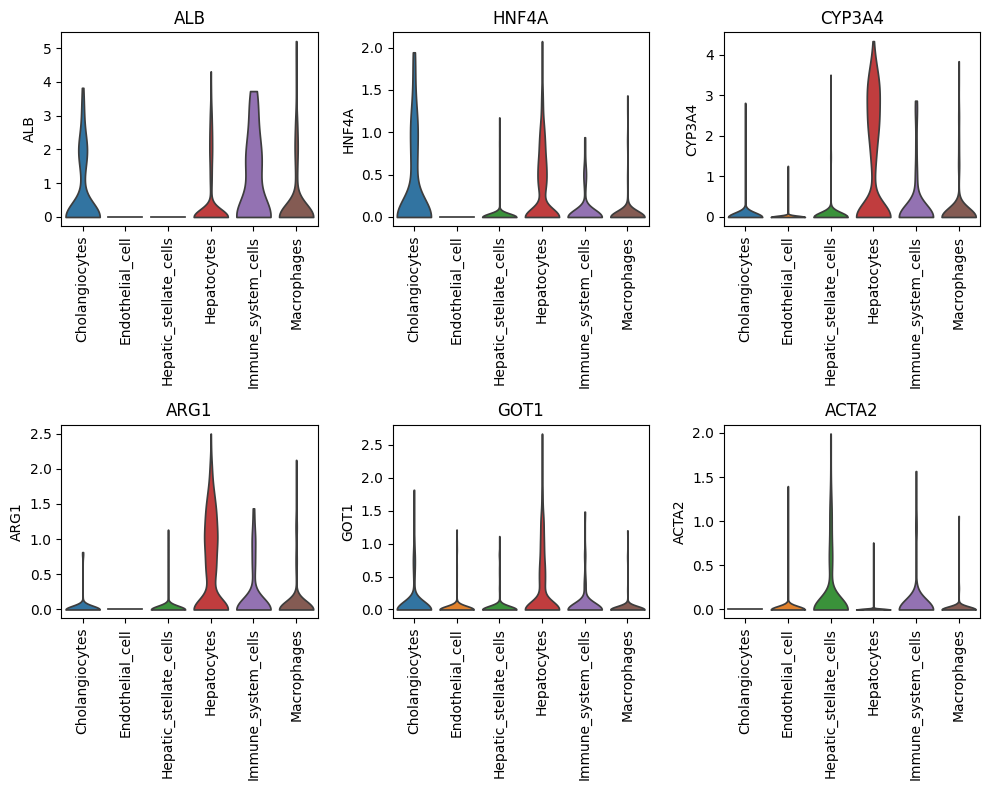

In [24]:
# plot violin with 2x3 grid layout
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for idx, gene in enumerate(genes):
    sc.pl.violin(
        adata,
        keys=gene,
        groupby="cellTypeHealthy",
        stripplot=False,
        rotation=90,
        multi_panel=False,
        ax=axes[idx],
        size=6,
        show=False
    )
    axes[idx].set_title(gene)

plt.tight_layout()
plt.show()